<a href="https://colab.research.google.com/github/Saurabh312Kumar/Deep_learning/blob/main/Cat_and_Dog_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torchvision import datasets, transforms

import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pf


In [5]:
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [6]:
device=('cuda' if torch.cuda.is_available else 'cpu')
print(f"Device is {device}")

Device is cuda


In [7]:
dataset_root = "/content/data"

full_dataset = datasets.OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="binary-category",
    download=True
)

print("Total images:", len(full_dataset))

100%|██████████| 792M/792M [00:44<00:00, 17.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.77MB/s]


Total images: 3680


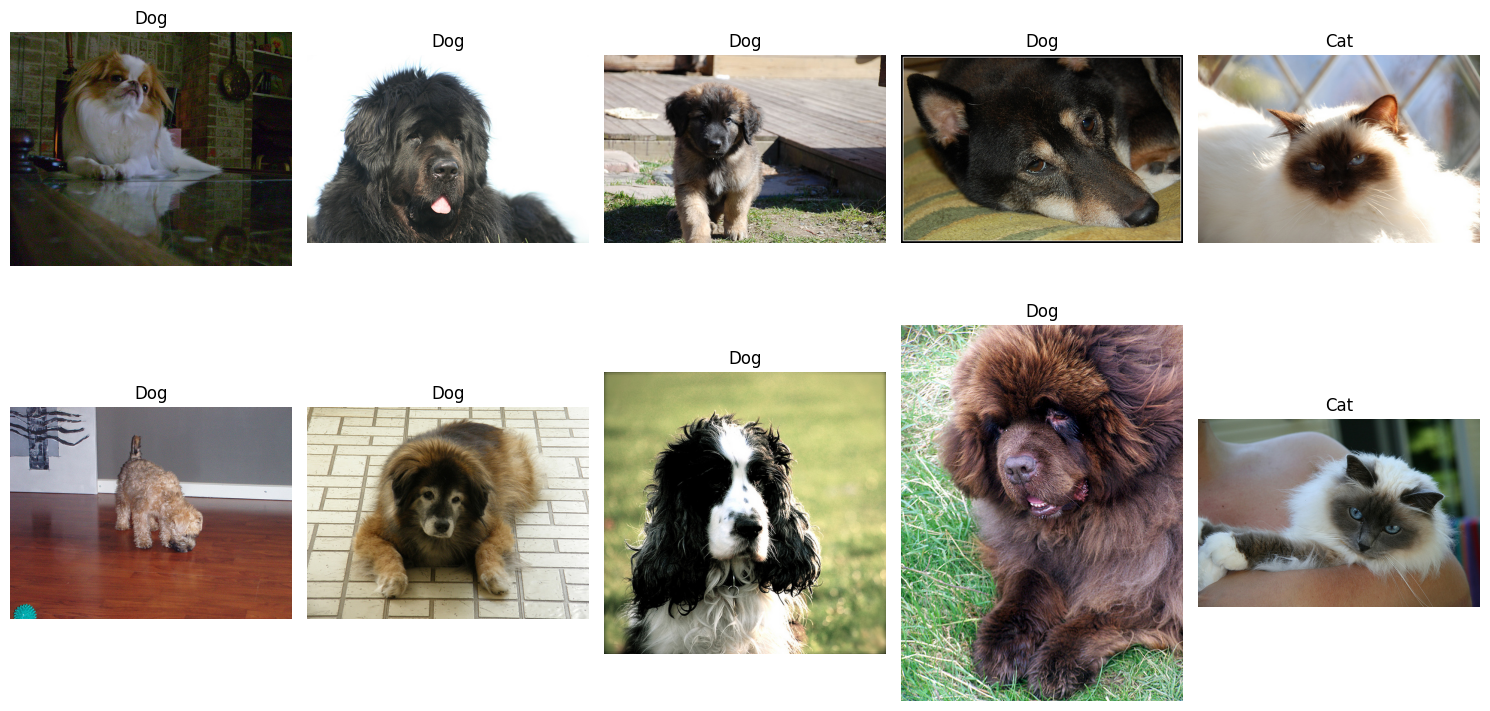

In [8]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15, 8))

for i in range(10):
    idx = random.randint(0, len(full_dataset) - 1)

    image, label = full_dataset[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title("Cat" if label == 0 else "Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
transform = transforms.Compose([
 transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [39]:
full_dataset = datasets.OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="binary-category",
    transform=transform,
    download=False
)

In [40]:
image, label = full_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 128, 128])
Label: 0


In [41]:
labels = [full_dataset[i][1] for i in range(len(full_dataset))]

print("Total samples:", len(labels))
print("Class 0:", labels.count(0))
print("Class 1:", labels.count(1))

Total samples: 3680
Class 0: 1188
Class 1: 2492


In [42]:
indices = np.arange(len(full_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))


Training samples: 2944
Validation samples: 736


In [43]:
from torch.utils.data.dataset import Subset
train_dataset=Subset(full_dataset, train_indices)
val_dataset=Subset(full_dataset, val_indices)

In [44]:
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [45]:
from torch.nn.modules.batchnorm import BatchNorm2d
class MyCnn(nn.Module):

  def __init__(self):
    super().__init__()
    self.features=nn.Sequential(
        nn.Conv2d(3,32,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifiers=nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*32*32,128),
        nn.ReLU(),
        nn.Dropout(p=0.2),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(64,2)
    )
  def forward(self,x):
    x=self.features(x)
    x=self.classifiers(x)

    return x

In [46]:
learning_rate=0.001
epochs=25

In [47]:
model=MyCnn()
model=model.to(device)


In [48]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=learning_rate,weight_decay=1e-4)

In [49]:
for epoch in range(epochs):
  total_loss=0
  for batch_feature,batch_label in train_loader:
    batch_feature=batch_feature.to(device)
    batch_label=batch_label.to(device)

    output=model(batch_feature)
    loss=criterion(output,batch_label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss=total_loss+loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/25, Loss: 0.9584270579659421
Epoch 2/25, Loss: 0.6400055218002071
Epoch 3/25, Loss: 0.6165697409406953
Epoch 4/25, Loss: 0.6029674744476443
Epoch 5/25, Loss: 0.5788703985188318
Epoch 6/25, Loss: 0.5510748242554457
Epoch 7/25, Loss: 0.5307818622044895
Epoch 8/25, Loss: 0.5109185262218766
Epoch 9/25, Loss: 0.5023056003062621
Epoch 10/25, Loss: 0.4656791680532953
Epoch 11/25, Loss: 0.4459134463382804
Epoch 12/25, Loss: 0.42256299973182054
Epoch 13/25, Loss: 0.39003137904016866
Epoch 14/25, Loss: 0.39129426087374275
Epoch 15/25, Loss: 0.3871795003828795
Epoch 16/25, Loss: 0.35790932291875716
Epoch 17/25, Loss: 0.3538688720892305
Epoch 18/25, Loss: 0.32487482496577763
Epoch 19/25, Loss: 0.3400496207177639
Epoch 20/25, Loss: 0.2968045328946217
Epoch 21/25, Loss: 0.28449728882507136
Epoch 22/25, Loss: 0.2846858592946892
Epoch 23/25, Loss: 0.25870906496825424
Epoch 24/25, Loss: 0.2532004832249621
Epoch 25/25, Loss: 0.23770172302813633


In [50]:
model.eval()

total=0
correct=0
with torch.no_grad():
  for batch_feature,batch_label in val_loader:
    batch_feature=batch_feature.to(device)
    batch_label=batch_label.to(device)

    output=model(batch_feature)

    _,predicted=torch.max(output,1)
    total=total+batch_label.shape[0]

    correct=correct+(predicted==batch_label).sum().item()

  print(f"Accuracy: {100*correct/total}%")




Accuracy: 74.04891304347827%


In [51]:
model.eval()

total=0
correct=0
with torch.no_grad():
  for batch_feature,batch_label in train_loader:
    batch_feature=batch_feature.to(device)
    batch_label=batch_label.to(device)

    output=model(batch_feature)

    _,predicted=torch.max(output,1)
    total=total+batch_label.shape[0]

    correct=correct+(predicted==batch_label).sum().item()

  print(f"Accuracy: {100*correct/total}%")

Accuracy: 94.42934782608695%


Save your trained model

In [52]:
torch.save(
    model.state_dict(),
    "oxford_pet_data_cnn.pth"
)

Load the model

In [53]:
model = MyCnn()

model.load_state_dict(
    torch.load(
        "oxford_pet_data_cnn.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

MyCnn(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifiers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [56]:
image, actual_label = val_dataset[3]

image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image_input)

    predicted_label = torch.argmax(
        output,
        dim=1
    ).item()

print("Actual label:", actual_label)
print("Predicted label:", predicted_label)

Actual label: 1
Predicted label: 1
